**CodeAlpha**

Task 1:
Iris Flower classification using Machine Learning

Objective



*   Sepal Length
*   Sepal Width
*   Petal Length
*   Petal width


Species


*   Setosa
*   Virginica
*   Versicolor





Dataset from kaggle : https://www.kaggle.com/datasets/saurabh00007/iriscsv?resource=download

In [65]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression

In [66]:
iris = pd.read_csv('Iris.csv')
iris

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


Data Describe


In [67]:
iris.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [68]:
iris.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [69]:
#checking columns before droping
print(iris.columns)

Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')


Handling missing values

In [70]:
iris.isnull().sum()

,0
Id,0
SepalLengthCm,0
SepalWidthCm,0
PetalLengthCm,0
PetalWidthCm,0
Species,0


Check for outliers

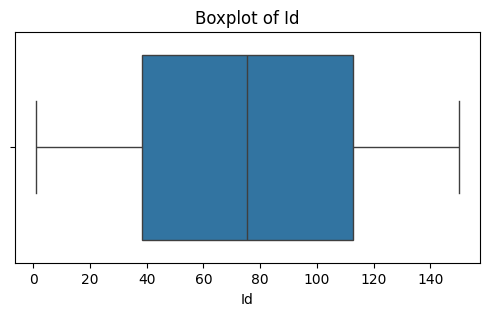

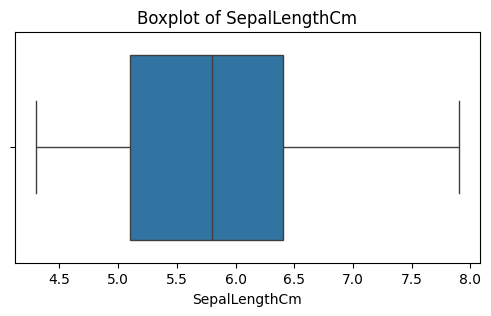

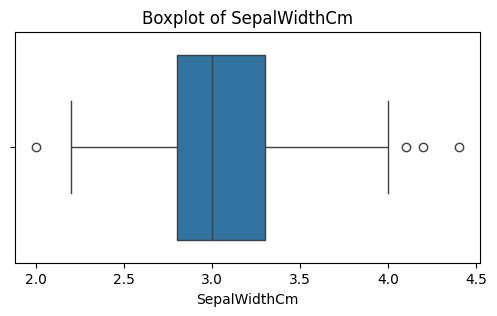

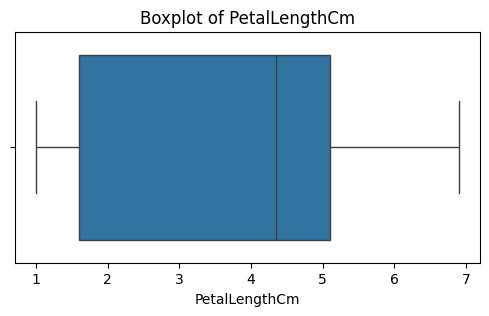

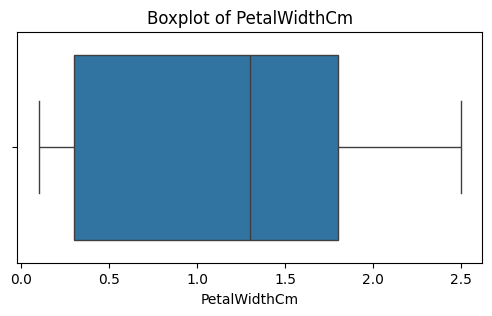

In [71]:
numeric_columns = iris.select_dtypes(include=[np.number]).columns.tolist()
for col in numeric_columns:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=iris[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

Capping outliers

In [72]:
# Function to cap outliers based on IQR
def cap_outliers(iris, column):
  Q1 = iris[column].quantile(0.25)
  Q3 = iris[column].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR
  iris[column] = np.clip(iris[column], lower_bound, upper_bound)

# Define columns outside the function so it's accessible to the loop
columns_to_cap = ['SepalLengthCm', 'SepalWidthCm',
                  'PetalLengthCm', 'PetalWidthCm']

for col in columns_to_cap:
    cap_outliers(iris, col)

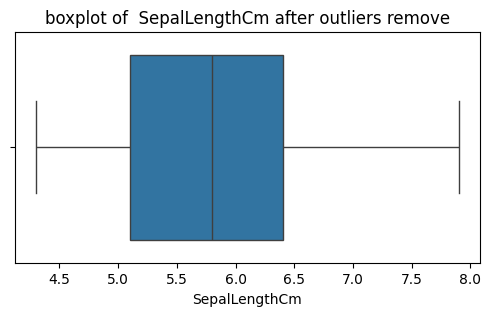

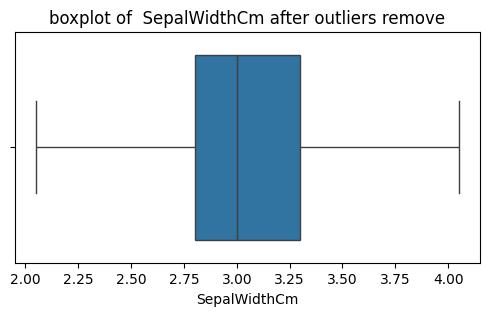

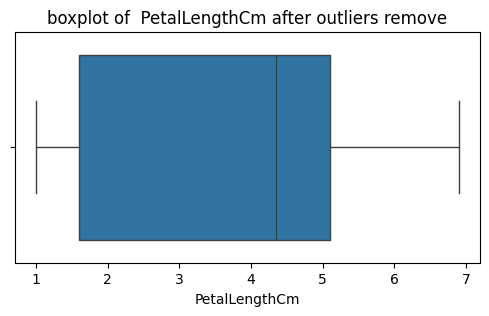

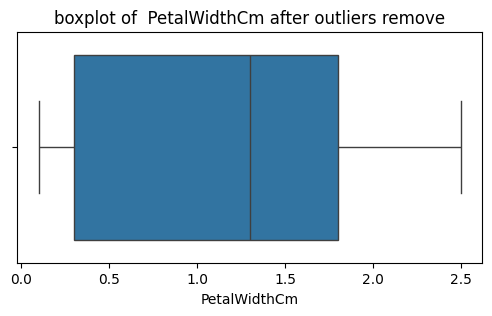

In [73]:
#visulaize boxplot after outliers removal
for col in columns_to_cap:
  plt.figure(figsize=(6,3))
  sns.boxplot(x=iris[col])
  plt.title(f'boxplot of  {col} after outliers remove')
  plt.show()


Data Visualization

<Figure size 1000x600 with 0 Axes>

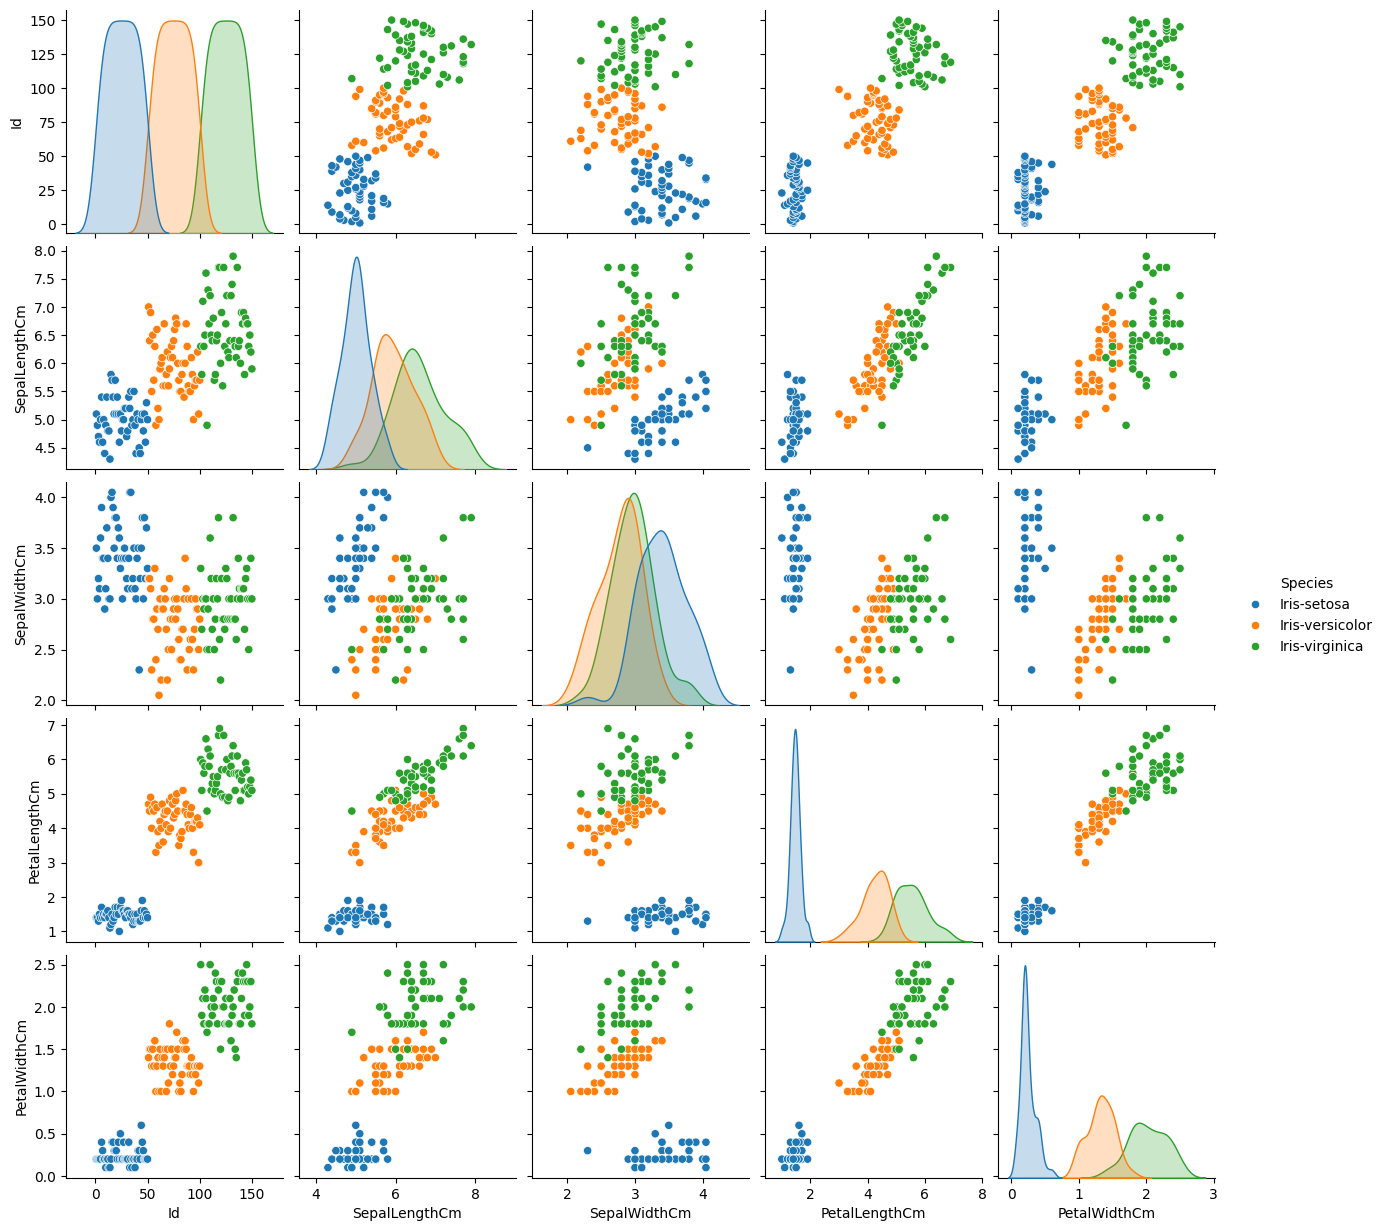

In [74]:
plt.figure(figsize=(10,6))
sns.pairplot(iris, hue='Species')
plt.show()

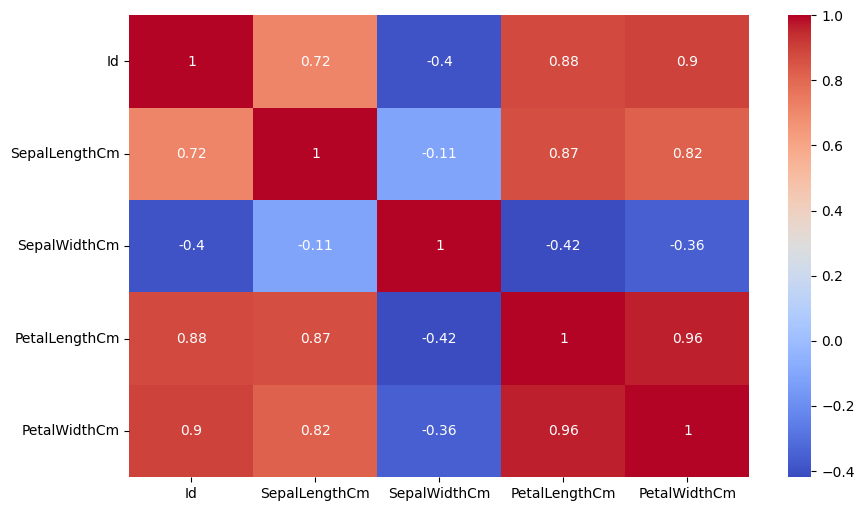

In [75]:
plt.figure(figsize=(10,6))
sns.heatmap(
    iris.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)
plt.show()

Data preprocessing

In [76]:
iris = iris.drop('Id', axis=1)
iris

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


In [77]:
#Label Encder to convert specious into number
le = LabelEncoder()
iris['Species'] = le.fit_transform(iris['Species'])
iris

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [78]:
X = iris.drop('Species', axis=1)
y = iris['Species']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [79]:
#Train machine learning model

model = LogisticRegression()
model.fit(X_train, y_train)

#Prediction
y_pred= model.predict(X_test)

#Model Evaluation
#accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy}')

#Classification report
class_report = classification_report(y_test, y_pred)
print(f'classification report:{class_report}')

#confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print(f'confusion matrix: {conf_matrix}')

Accuracy: 1.0
classification report:              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

confusion matrix: [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


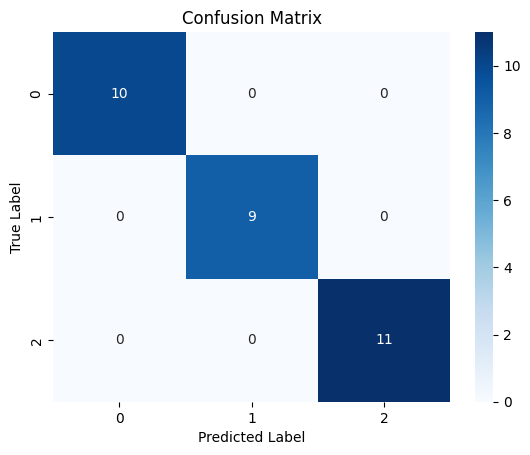

In [80]:
conf_matrix_hp = confusion_matrix(y_test, y_pred)

sns.heatmap(conf_matrix_hp, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

The confusion matrix shows that the model classified all flower species correctly no misclassifications, resulting 100% accuracy on the data set